# 07 the greeks

The Greeks measure how sensitive an option's price is to each input, which we can use to understand risk.
| greek | symbol | measures sensitivity to |
|-------|--------|------------------------|
| Delta | Δ | Stock price |
| Gamma | Γ | Rate of change of delta |
| Vega  | ν | Volatility |
| Theta | Θ | Time to expiry |
| Rho   | ρ | Risk-free rate |

We will use finite differences to estimate each greek numerically. We bump an input by some small amount $h$, reprice, then divide by $h$.

In [1]:
import sys
sys.path.append('../src')

import numpy as np
import matplotlib.pyplot as plt
from pricer import bs_pricing, mc_pricing, compute_greeks

## Finite difference approximation

For any Greek we use the central difference formula:

$$\frac{\partial P}{\partial x} \approx \frac{P(x+h) - P(x-h)}{2h}$$

Central differences are more accurate than one-sided differences because the errors cancel to second order.

In [2]:
Sof0  = 100
K     = 105
r     = 0.05
sigma = 0.20
T     = 1.0

greeks = compute_greeks(Sof0, K, r, sigma, T, option_type='call')

print("Greeks for a large-cap call option")
print(f"  Price : ${greeks['price']:.4f}")
print(f"  Delta :  {greeks['delta']:.4f}  (price moves ${greeks['delta']:.2f} per $1 move in stock)")
print(f"  Gamma :  {greeks['gamma']:.4f}  (delta changes {greeks['gamma']:.4f} per $1 move in stock)")
print(f"  Vega  :  {greeks['vega']:.4f}  (price moves ${greeks['vega']:.4f} per 1% move in vol)")
print(f"  Theta :  {greeks['theta']:.4f}  (price loses ${abs(greeks['theta']):.4f} per day)")
print(f"  Rho   :  {greeks['rho']:.4f}  (price moves ${greeks['rho']:.4f} per 1% move in rates)")

Greeks for a large-cap call option
  Price : $8.0214
  Delta :  0.5422  (price moves $0.54 per $1 move in stock)
  Gamma :  0.0198  (delta changes 0.0198 per $1 move in stock)
  Vega  :  0.3967  (price moves $0.3967 per 1% move in vol)
  Theta :  -0.0172  (price loses $0.0172 per day)
  Rho   :  0.4620  (price moves $0.4620 per 1% move in rates)


## Delta across stock prices

Delta tells you how much the option moves for each $1 move in the stock.

- Delta near 0 → deep out of the money, option barely responds to stock moves
- Delta near 0.5 → at the money
- Delta near 1 → deep in the money, option moves dollar-for-dollar with stock

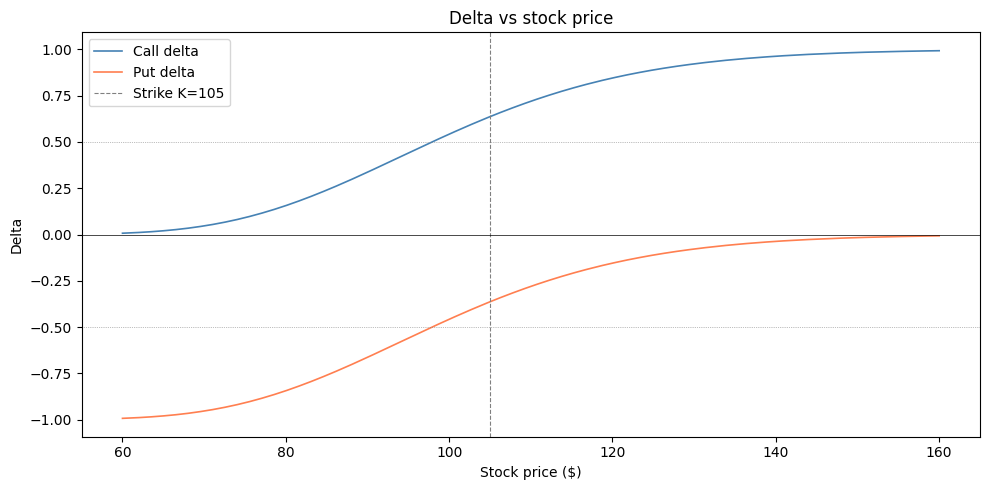

In [3]:
stock_prices = np.linspace(60, 160, 200)

deltas_call = [compute_greeks(S, K, r, sigma, T, option_type='call')['delta']
               for S in stock_prices]
deltas_put  = [compute_greeks(S, K, r, sigma, T, option_type='put')['delta']
               for S in stock_prices]

plt.figure(figsize=(10, 5))
plt.plot(stock_prices, deltas_call, color='steelblue', linewidth=1.2, label='Call delta')
plt.plot(stock_prices, deltas_put,  color='coral',     linewidth=1.2, label='Put delta')
plt.axvline(K,    color='gray', linestyle='--', linewidth=0.8, label=f'Strike K={K}')
plt.axhline(0,    color='black', linewidth=0.5)
plt.axhline(0.5,  color='gray',  linewidth=0.5, linestyle=':')
plt.axhline(-0.5, color='gray',  linewidth=0.5, linestyle=':')
plt.xlabel('Stock price ($)')
plt.ylabel('Delta')
plt.title('Delta vs stock price')
plt.legend()
plt.tight_layout()
plt.show()

## Gamma across stock prices

Gamma is highest at the money and near expiry — this is when the option's delta is most sensitive to stock moves. High gamma means a delta hedge needs frequent rebalancing, which is expensive.

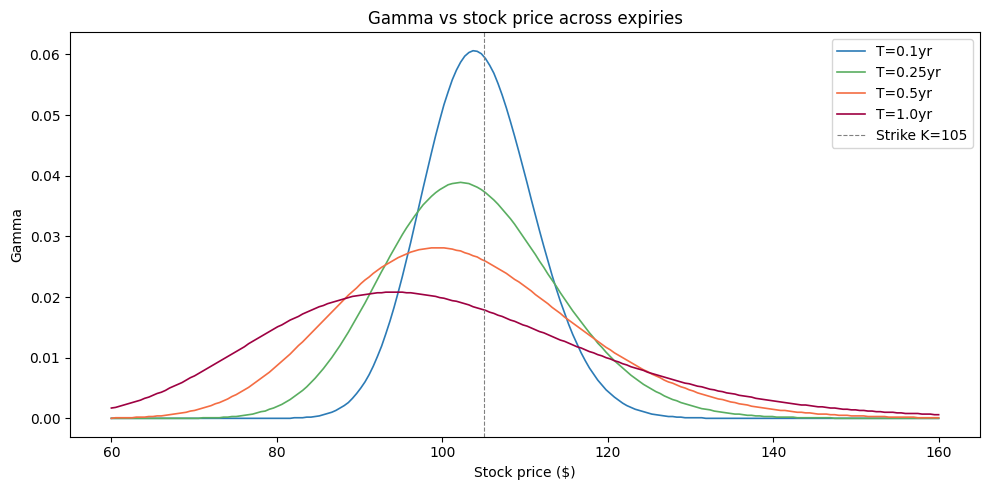

In [4]:
T_values = [0.1, 0.25, 0.5, 1.0]
colors   = ['#2c7bb6', '#5aae61', '#f46d43', '#9e0142']

plt.figure(figsize=(10, 5))
for T_val, color in zip(T_values, colors):
    gammas = [compute_greeks(S, K, r, sigma, T_val, option_type='call')['gamma']
              for S in stock_prices]
    plt.plot(stock_prices, gammas, color=color, linewidth=1.2, label=f'T={T_val}yr')

plt.axvline(K, color='gray', linestyle='--', linewidth=0.8, label=f'Strike K={K}')
plt.xlabel('Stock price ($)')
plt.ylabel('Gamma')
plt.title('Gamma vs stock price across expiries')
plt.legend()
plt.tight_layout()
plt.show()

## Vega across stock prices

Vega measures how much the option price changes per 1% move in volatility. It is highest at the money — an at-the-money option is most sensitive to vol changes because uncertainty about whether it finishes in or out of the money is maximized there.

In [ ]:
vegas = [compute_greeks(S, K, r, sigma, T, option_type='call')['vega']
         for S in stock_prices]

plt.figure(figsize=(10, 5))
plt.plot(stock_prices, vegas, color='steelblue', linewidth=1.2)
plt.axvline(K, color='gray', linestyle='--', linewidth=0.8, label=f'Strike K={K}')
plt.xlabel('Stock price ($)')
plt.ylabel('Vega ($ per 1% vol move)')
plt.title('Vega vs stock price')
plt.legend()
plt.tight_layout()
plt.show()

## Theta decay

Theta is the daily time decay of the option, that being how much value it loses each day just from time passing. It is always negative for long options as you lose value as expiry approaches. The decay accelerates as expiry approaches, as an option loses more value in its final week than in an entire month a year out, since there is less time to hit the strike price.

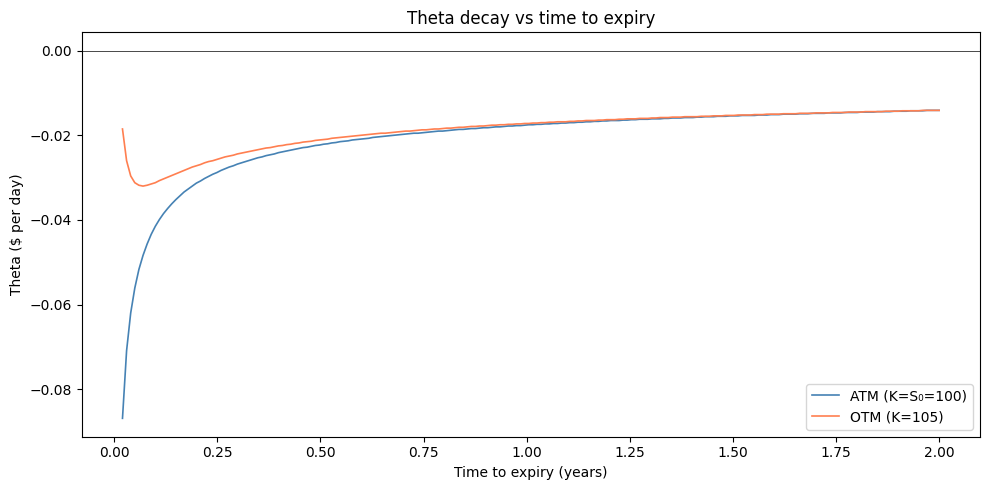

In [5]:
time_to_expiry = np.linspace(0.02, 2.0, 200)

thetas_atm = [compute_greeks(Sof0, Sof0, r, sigma, t, option_type='call')['theta']
              for t in time_to_expiry]
thetas_otm = [compute_greeks(Sof0, K, r, sigma, t, option_type='call')['theta']
              for t in time_to_expiry]

plt.figure(figsize=(10, 5))
plt.plot(time_to_expiry, thetas_atm, color='steelblue', linewidth=1.2, label='ATM (K=S₀=100)')
plt.plot(time_to_expiry, thetas_otm, color='coral',     linewidth=1.2, label=f'OTM (K={K})')
plt.axhline(0, color='black', linewidth=0.5)
plt.xlabel('Time to expiry (years)')
plt.ylabel('Theta ($ per day)')
plt.title('Theta decay vs time to expiry')
plt.legend()
plt.tight_layout()
plt.show()

## Monte Carlo Greeks

We can estimate the same Greeks using Monte Carlo bump-and-reprice. With enough paths, the results should closely match the Black-Scholes Greeks above.

In [6]:
N, M = 252, 20000
h    = 1.0   # larger bump for MC because of sampling noise

mc_delta = (mc_pricing(Sof0+h, K, r, sigma, T, N, M, seed=42) -
            mc_pricing(Sof0-h, K, r, sigma, T, N, M, seed=42)) / (2*h)

mc_vega  = (mc_pricing(Sof0, K, r, sigma+0.01, T, N, M, seed=42) -
            mc_pricing(Sof0, K, r, sigma-0.01, T, N, M, seed=42)) / (2*0.01) / 100

bs_delta = greeks['delta']
bs_vega  = greeks['vega']

print("Greeks comparison — Monte Carlo vs Black-Scholes")
print(f"  Delta : MC = {mc_delta:.4f}  |  BS = {bs_delta:.4f}  |  diff = {abs(mc_delta-bs_delta):.4f}")
print(f"  Vega  : MC = {mc_vega:.4f}  |  BS = {bs_vega:.4f}  |  diff = {abs(mc_vega-bs_vega):.4f}")

Greeks comparison — Monte Carlo vs Black-Scholes
  Delta : MC = 0.5469  |  BS = 0.5422  |  diff = 0.0047
  Vega  : MC = 0.4067  |  BS = 0.3967  |  diff = 0.0100
